In [ ]:
%pip install numpy matplotlib scipy PyWavelets

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.fft import fft, fftfreq
import pywt

colors = {'blue':'#4285F4', 'red': '#EA4335', 'yellow': '#FBBC05', 'green': '#34A853'}

# Part 1: Βαθυπερατό Φίλτρο

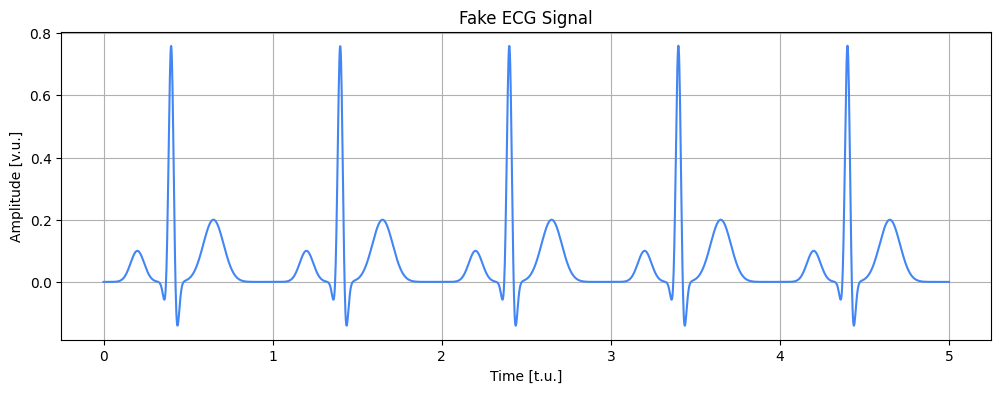

In [6]:
def generate_fake_ecg(duration, fs):
    t = np.linspace(0, duration, int(fs * duration))
    ecg = np.zeros_like(t)

    # P, Q, R, S, T peaks and widths
    peaks = {
        'P': (0.20,  0.10, 0.040), 
        'Q': (0.37, -0.10, 0.015), 
        'R': (0.40,  0.80, 0.015),
        'S': (0.43, -0.20, 0.015), 
        'T': (0.65,  0.20, 0.060)
    }

    for i in range(int(duration)):
        for _, (pos, amp, width) in peaks.items():
            peak_time = i + pos
            # add a pulse to the ecg signal
            ecg += amp * np.exp(-((t - peak_time)**2) / (2 * width**2))
    return t, ecg


duration = 5
fs = 500
t, original = generate_fake_ecg(duration, fs)

plt.figure(figsize=(12, 4))
plt.plot(t, original, color=colors['blue'])
plt.title('Fake ECG Signal')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)
plt.show()

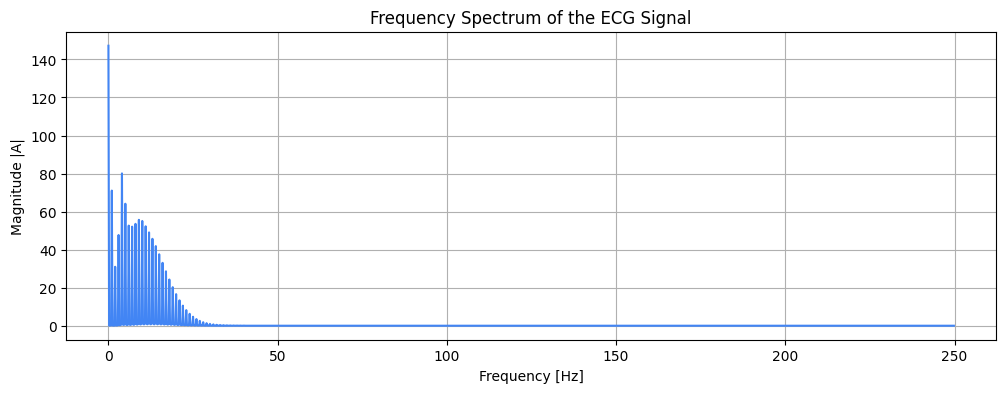

In [7]:
n = len(original)
yf = fft(original)
xf = fftfreq(n, 1/fs)

plt.figure(figsize=(12, 4))
plt.plot(xf[0:n//2], abs(yf[0:n//2]), color=colors['blue'])
plt.title('Frequency Spectrum of the ECG Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude |A|')
plt.grid(True)
plt.show()

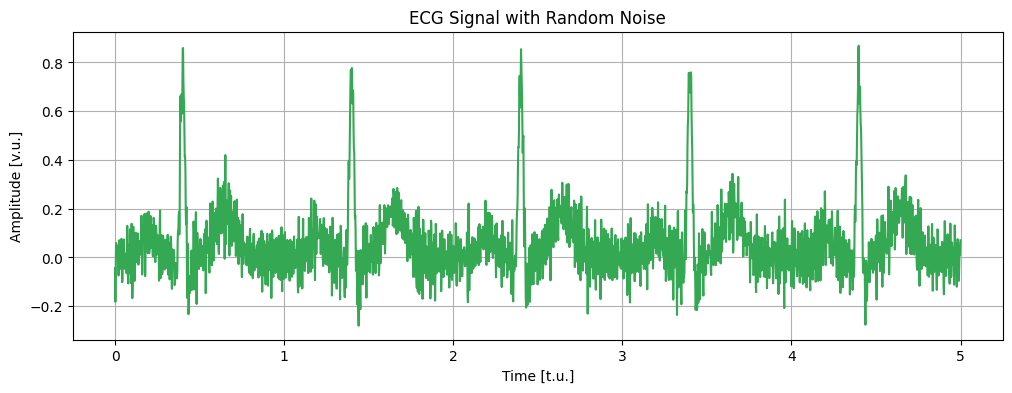

In [8]:
def add_noice(signal, lb_freq, ub_freq, fs):
    noise = np.zeros_like(signal)
    for _ in range(42):
        freq = np.random.uniform(lb_freq, ub_freq)
        phase = np.random.uniform(0, 2*np.pi)
        amplitude = np.random.uniform(1/100, 2/100)
        noise += amplitude * np.sin(2 * np.pi * freq * t + phase)
    return signal + noise

# Applying the random sine-sum noise
low_freq = 50
high_freq = 150
signal = add_noice(original, low_freq, high_freq, fs=fs)

plt.figure(figsize=(12, 4))
plt.plot(t, signal, color=colors['green'])
plt.title('ECG Signal with Random Noise')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)
plt.show()

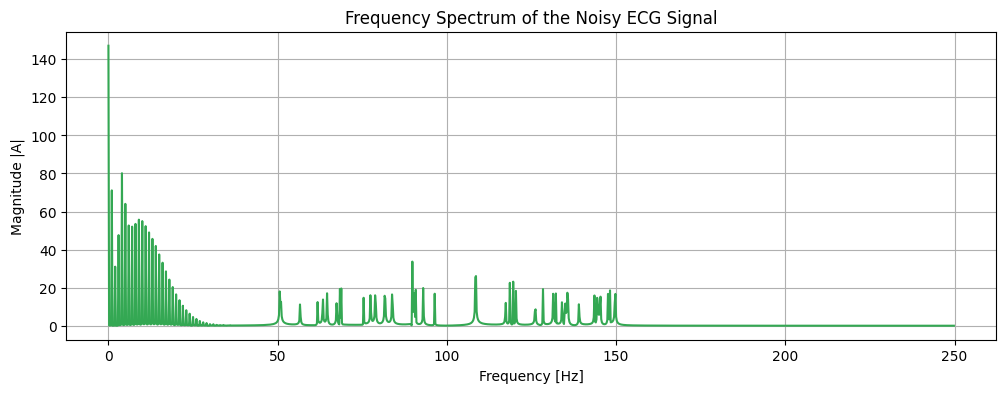

In [9]:
n = len(signal)
yf = fft(signal)
xf = fftfreq(n, 1/fs)

plt.figure(figsize=(12, 4))
plt.plot(xf[0:n//2], abs(yf[0:n//2]), color=colors['green'])
plt.title('Frequency Spectrum of the Noisy ECG Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude |A|')
plt.grid(True)
plt.show()

In [10]:
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

cutoff = 50
filtered = butter_lowpass_filter(signal, cutoff, fs)

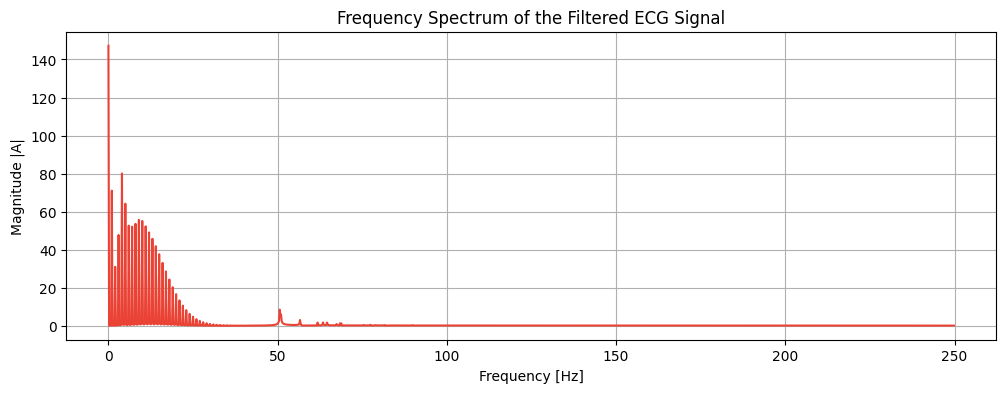

In [11]:
n = len(filtered)
yf = fft(filtered)
xf = fftfreq(n, 1/fs)

plt.figure(figsize=(12, 4))
plt.plot(xf[0:n//2], abs(yf[0:n//2]), color=colors['red'])
plt.title('Frequency Spectrum of the Filtered ECG Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude |A|')
plt.grid(True)
plt.show()

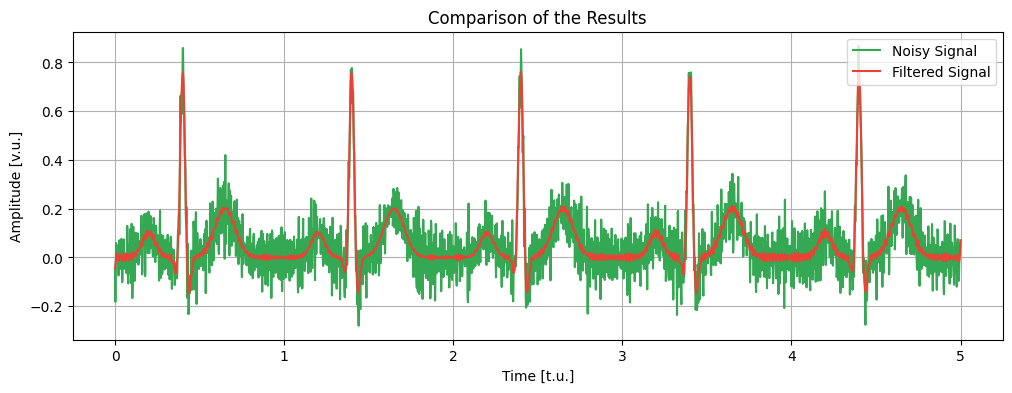

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(t, signal, label='Noisy Signal', color=colors['green'])
plt.plot(t, filtered, label='Filtered Signal', color=colors['red'])
plt.title('Comparison of the Results')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.legend()
plt.grid(True)
plt.show()

# Part 2: Φίλτρο Κινούμενου Μέσου

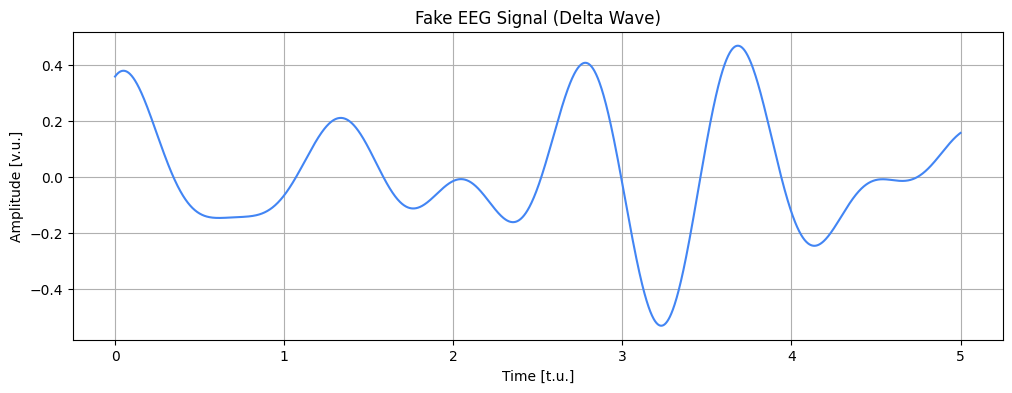

In [13]:
def generate_fake_delta_eeg(duration, fs):
    np.random.seed(1742)
    t = np.linspace(0, duration, int(fs * duration))
    sin_no = 3
    freqs = [np.random.uniform(0.5, 4) for _ in range(sin_no)]
    amps = [np.random.uniform(75, 200) for _ in range(sin_no)]
    phases = [np.random.uniform(0, 2*np.pi) for _ in range(sin_no)]

    eeg_signal = np.zeros_like(t)
    for f, a, p in zip(freqs, amps, phases):
        eeg_signal += a * np.sin(2 * np.pi * f * t + p)

    eeg_signal = eeg_signal / (eeg_signal.max() - eeg_signal.min())
    return t, eeg_signal

duration = 5
fs = 500
t, original = generate_fake_delta_eeg(duration, fs)

plt.figure(figsize=(12, 4))
plt.plot(t, original, color=colors['blue'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)
plt.show()

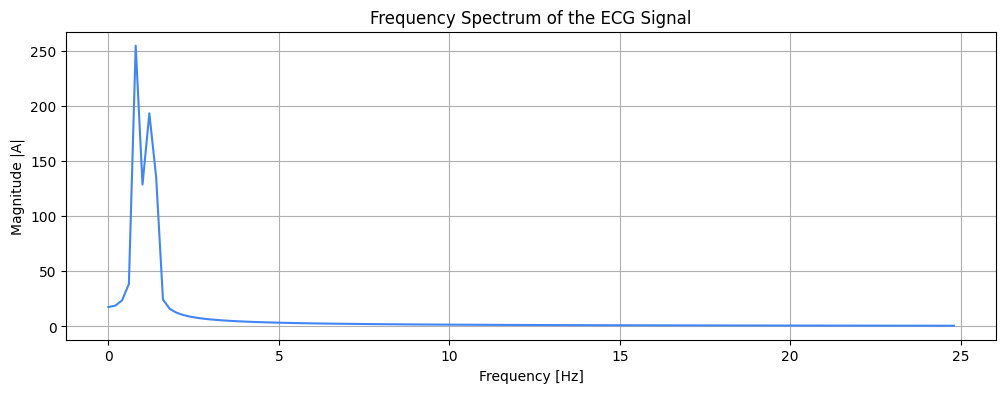

In [14]:
n = len(original)
yf = fft(original)
xf = fftfreq(n, 1/fs)

plt.figure(figsize=(12, 4))
plt.plot(xf[0:n//20], abs(yf[0:n//20]), color=colors['blue'])
plt.title('Frequency Spectrum of the ECG Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude |A|')
plt.grid(True)
plt.show()

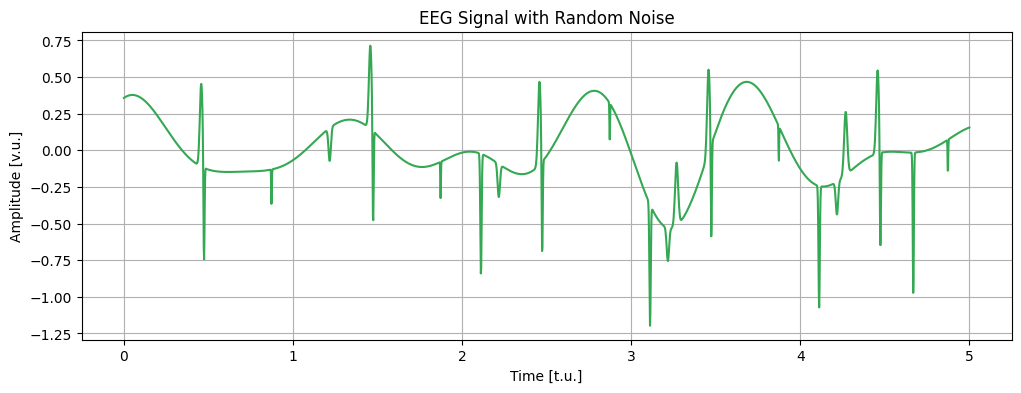

In [15]:
def add_noice(signal):
    np.random.seed(1742)
    noise = np.zeros_like(signal)
    jiter_no = 7
    pos = [np.random.uniform(0, duration) for _ in range(jiter_no)]
    amp = [np.random.uniform(-1, 1) for _ in range(jiter_no)]
    width = [np.random.uniform(1/1000, 1/100) for _ in range(jiter_no)]

    for i in range(int(duration)):
        for j in range(int(jiter_no)):
            peak_time = i + pos[j]
            noise += amp[j] * np.exp(-((t - peak_time)**2) / (2 * width[j]**2))
    return signal + noise

signal = add_noice(original)

plt.figure(figsize=(12, 4))
plt.plot(t, signal, color=colors['green'])
plt.title('EEG Signal with Random Noise')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)
plt.show()

In [16]:
def sma(signal, k):
    out = np.full_like(signal, np.nan, dtype=float)
    for i in range(k - 1, len(signal)):
        out[i] = np.median(signal[i - k + 1 : i + 1])
    return out

k = 42
filtered = sma(signal=signal, k=k)

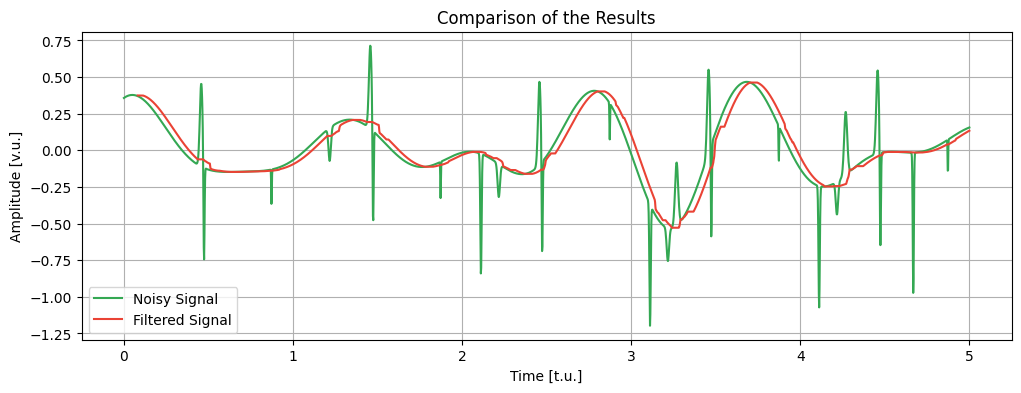

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(t, signal, label='Noisy Signal', color=colors['green'])
plt.plot(t, filtered, label='Filtered Signal', color=colors['red'])
plt.title('Comparison of the Results')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.legend()
plt.grid(True)
plt.show()

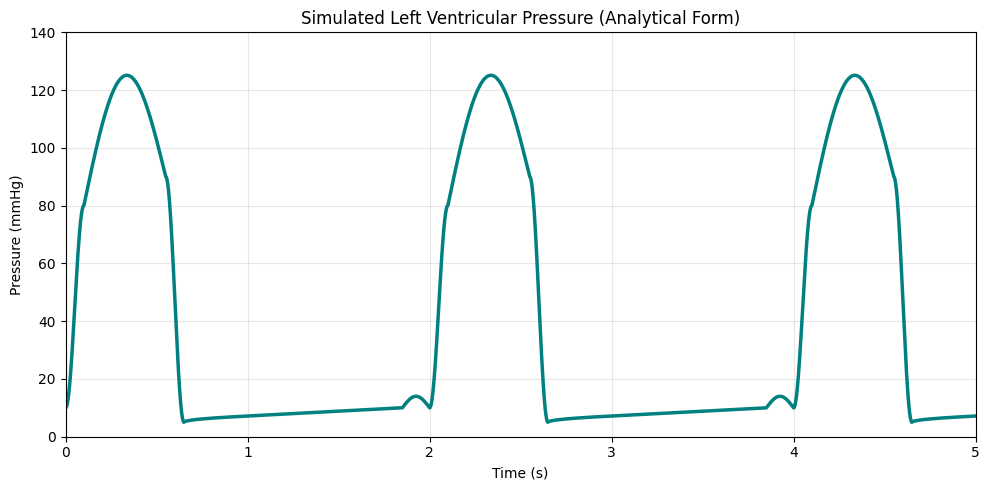

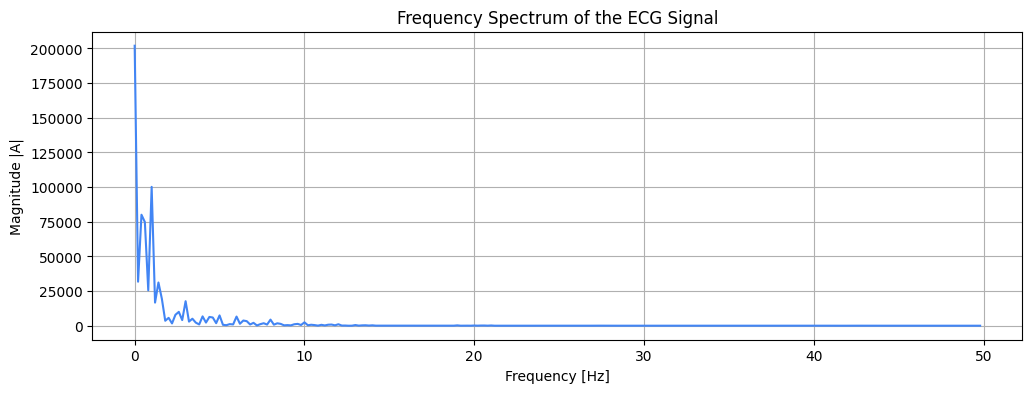

In [41]:
def analytical_ventricular_pressure(t):
    t_mod = t % 2.0
    
    # 1. Define boolean masks for the domain segments
    c1 = (t_mod >= 0.0) & (t_mod < 0.1)   # Isovolumetric Contraction
    c2 = (t_mod >= 0.1) & (t_mod < 0.55)  # Ejection
    c3 = (t_mod >= 0.55) & (t_mod < 0.65) # Isovolumetric Relaxation
    c4 = (t_mod >= 0.65) & (t_mod < 0.95) # Rapid Filling
    c5 = (t_mod >= 0.95) & (t_mod < 1.85) # Diastasis
    c6 = (t_mod >= 1.85) & (t_mod <= 2.0) # Atrial Systole
    
    # 2. Define the corresponding mathematical mappings
    f1 = lambda x: 10.0 + 70.0 * (1.0 - np.cos(np.pi * x / 0.1)) / 2.0
    f2 = lambda x: 80.0 + 40.0 * np.sin(np.pi * (x - 0.1) / 0.45) + 10.0 * (x - 0.1) / 0.45
    f3 = lambda x: 5.0 + 85.0 * (1.0 + np.cos(np.pi * (x - 0.55) / 0.1)) / 2.0
    f4 = lambda x: 5.0 + 2.0 * np.sqrt((x - 0.65) / 0.30)
    f5 = lambda x: 7.0 + 3.0 * (x - 0.95) / 0.90
    f6 = lambda x: 10.0 + 4.0 * np.sin(np.pi * (x - 1.85) / 0.15)
    
    # 3. Assemble and return the piecewise evaluation
    return np.piecewise(t_mod, [c1, c2, c3, c4, c5, c6], [f1, f2, f3, f4, f5, f6])

fs = 1000 
t_total = 5.0
t = np.linspace(0, t_total, int(t_total * fs))

p_signal = analytical_ventricular_pressure(t)

# Plotting the result
plt.figure(figsize=(10, 5))
plt.plot(t, p_signal, color='teal', linewidth=2.5)
plt.title('Simulated Left Ventricular Pressure (Analytical Form)')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (mmHg)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 140)

plt.tight_layout()
plt.show()

n = len(p_signal)
yf = fft(p_signal)
xf = fftfreq(n, 1/fs)

plt.figure(figsize=(12, 4))
plt.plot(xf[0:n//20], abs(yf[0:n//20]), color=colors['blue'])
plt.title('Frequency Spectrum of the ECG Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude |A|')
plt.grid(True)
plt.show()

# Part 3: Wavelet Transformation

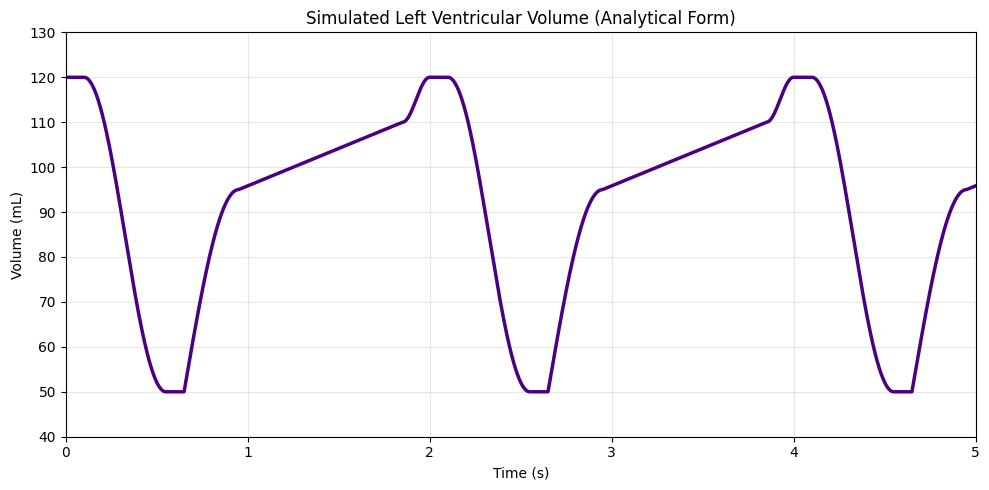

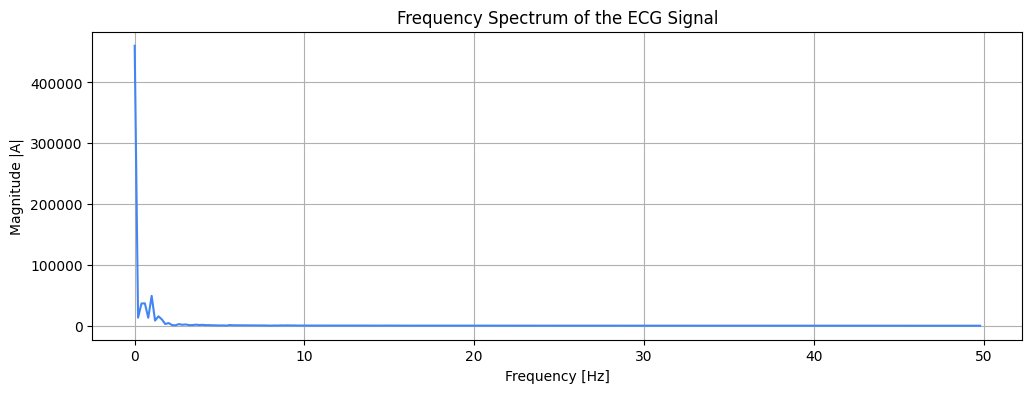

In [40]:
def analytical_ventricular_volume(t):
    """Calculates ventricular volume at time t using analytical piecewise functions."""
    # Enforce periodicity
    t_mod = t % 2.0
    
    # 1. Define boolean masks for the domain segments
    c1 = (t_mod >= 0.0) & (t_mod < 0.1)   # Isovolumetric Contraction
    c2 = (t_mod >= 0.1) & (t_mod < 0.55)  # Ejection
    c3 = (t_mod >= 0.55) & (t_mod < 0.65) # Isovolumetric Relaxation
    c4 = (t_mod >= 0.65) & (t_mod < 0.95) # Rapid Filling
    c5 = (t_mod >= 0.95) & (t_mod < 1.85) # Diastasis
    c6 = (t_mod >= 1.85) & (t_mod <= 2.0) # Atrial Systole
    
    # 2. Define the corresponding mathematical mappings
    # Using lambdas so we only evaluate functions on the appropriate slices of t
    f1 = lambda x: np.full_like(x, 120.0)
    f2 = lambda x: 50.0 + 70.0 * (1 + np.cos(np.pi * (x - 0.1) / 0.45)) / 2.0
    f3 = lambda x: np.full_like(x, 50.0)
    f4 = lambda x: 50.0 + 45.0 * np.sin((np.pi / 2.0) * (x - 0.65) / 0.30)
    f5 = lambda x: 95.0 + 15.0 * (x - 0.95) / 0.90
    f6 = lambda x: 110.0 + 10.0 * (1 - np.cos(np.pi * (x - 1.85) / 0.15)) / 2.0
    
    # 3. Assemble and return the piecewise evaluation
    return np.piecewise(t_mod, [c1, c2, c3, c4, c5, c6], [f1, f2, f3, f4, f5, f6])

# Set parameters and compute
fs = 1000 
t_total = 5.0
t = np.linspace(0, t_total, int(t_total * fs))

v_signal = analytical_ventricular_volume(t)

# Plotting the result
plt.figure(figsize=(10, 5))
plt.plot(t, v_signal, color='indigo', linewidth=2.5)
plt.title('Simulated Left Ventricular Volume (Analytical Form)')
plt.xlabel('Time (s)')
plt.ylabel('Volume (mL)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(40, 130)

plt.tight_layout()
plt.show()

n = len(v_signal)
yf = fft(v_signal)
xf = fftfreq(n, 1/fs)

plt.figure(figsize=(12, 4))
plt.plot(xf[0:n//20], abs(yf[0:n//20]), color=colors['blue'])
plt.title('Frequency Spectrum of the ECG Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude |A|')
plt.grid(True)
plt.show()

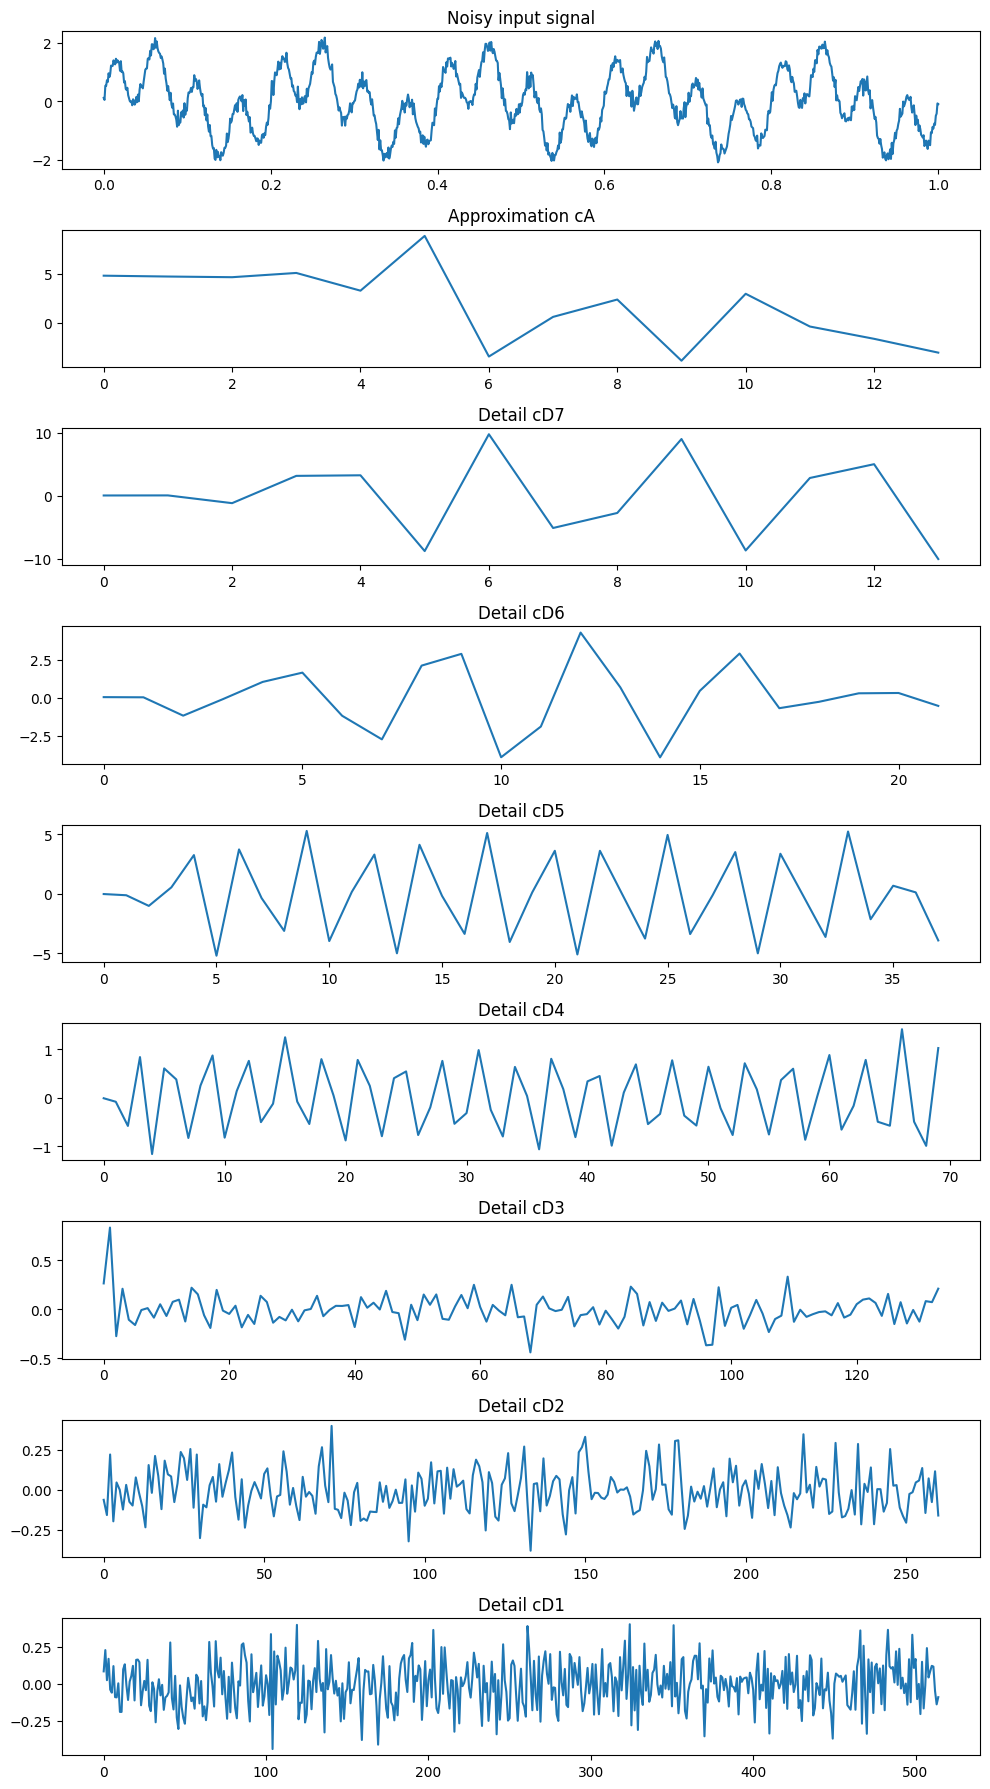

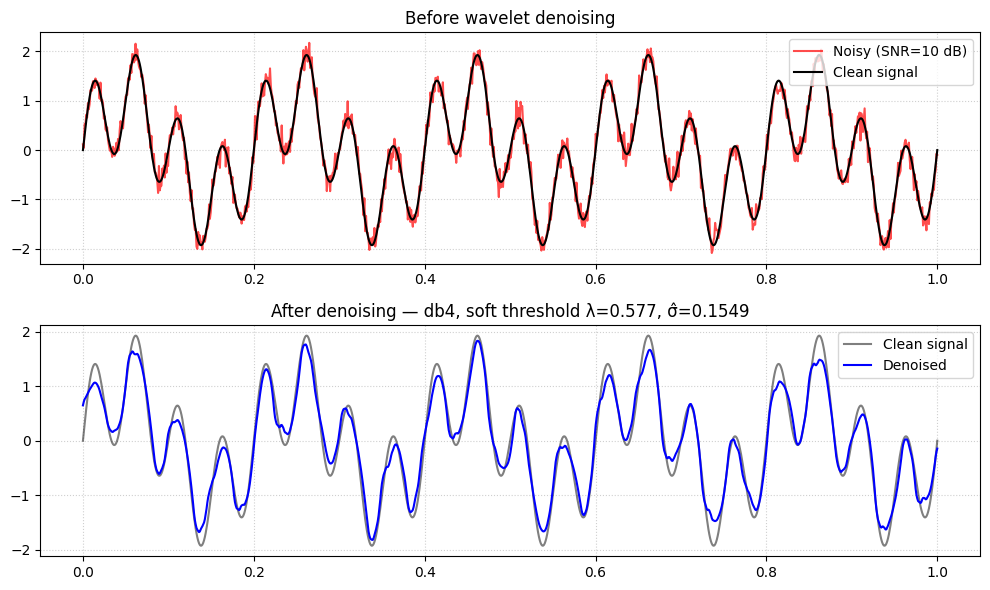

SNR before denoising : 17.01 dB
SNR after denoising  : 14.71 dB


In [35]:
# ── Signal generation ─────────────────────────────────────────────────────────
t = np.linspace(0, 1, 1024)
clean_signal = np.sin(2 * np.pi * 5 * t) + np.sin(2 * np.pi * 20 * t)

def awgn(signal, snr_db):
    signal = np.asarray(signal, dtype=complex if np.iscomplexobj(signal) else float)
    P_s = np.mean(np.abs(signal) ** 2)
    snr_linear = 10 ** (snr_db / 10)
    P_n = P_s / snr_linear
    std = np.sqrt(P_n / 2) if np.iscomplexobj(signal) else np.sqrt(P_n)
    noise = (std * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
             if np.iscomplexobj(signal) else std * np.random.randn(*signal.shape))
    return signal + noise

# ✅ Fix 1: sensible SNR; Fix 2: use 'measured' 
noisy_signal = awgn(clean_signal, snr_db=17)

# ── Wavelet decomposition ─────────────────────────────────────────────────────
wavelet = 'db4'
# wavedec returns [cA_n, cD_n, cD_{n-1}, ..., cD_1]
# i.e. coeffs[0]  = coarse approximation (lowest freq)
#      coeffs[-1] = finest detail (highest freq, most noise)
coeffs = pywt.wavedec(noisy_signal, wavelet)

# ── Plot decomposition ────────────────────────────────────────────────────────
n_plots = len(coeffs) + 1
# ✅ Fix 3: correct level labels
titles = (["Noisy input signal", "Approximation cA"]
          + [f"Detail cD{i}" for i in range(len(coeffs) - 1, 0, -1)])

plt.figure(figsize=(10, 2 * n_plots))
plt.subplot(n_plots, 1, 1)
plt.plot(t, noisy_signal)
plt.title(titles[0])

for i, coeff in enumerate(coeffs):
    plt.subplot(n_plots, 1, i + 2)
    plt.plot(coeff)
    plt.title(titles[i + 1])

plt.tight_layout()
plt.show()

# ── Step 1: noise variance estimate via MAD on finest detail band ─────────────
# cD1 (coeffs[-1]) is the highest-frequency subband — dominated by noise.
# MAD estimator: σ̂ = MAD / 0.6745
# The 0.6745 constant = Φ⁻¹(0.75) — it converts MAD to a consistent
# estimator of σ for a Gaussian distribution.
cD1  = coeffs[-1]
mad  = np.median(np.abs(cD1 - np.median(cD1)))
sigma = mad / 0.6745

# ── Step 2: universal (Donoho-Johnstone) threshold ───────────────────────────
# λ = σ√(2 ln N)  — asymptotically optimal for removing Gaussian noise
# while preserving signal features. Derived from the expected maximum
# of N i.i.d. N(0,1) variables.
N = len(noisy_signal)
lambda_thr = sigma * np.sqrt(2 * np.log(N))

# ── Step 3: soft thresholding on detail coefficients only ────────────────────
# Soft threshold: sign(x) * max(|x| - λ, 0)
# Shrinks all coefficients toward zero — avoids hard-threshold's
# discontinuity (Gibbs-like artefacts) at the cost of slight bias.
# cA (coeffs[0]) is NOT thresholded — it encodes the signal's DC/low-freq
# structure and thresholding it would distort the baseline.
denoised_coeffs = [coeffs[0]] + [
    pywt.threshold(c, value=lambda_thr, mode='soft')
    for c in coeffs[1:]
]

# ── Step 4: inverse DWT ───────────────────────────────────────────────────────
reconstructed = pywt.waverec(denoised_coeffs, wavelet)
# waverec can return length 1025 due to odd-length padding — trim to match t
reconstructed = reconstructed[:len(t)]

# ── Step 5: plot results ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, noisy_signal,  color='red',   alpha=0.7, label=f'Noisy (SNR=10 dB)')
plt.plot(t, clean_signal,  color='black', lw=1.5,    label='Clean signal')
plt.title('Before wavelet denoising')
plt.legend(); plt.grid(True, ls=':', alpha=0.6)

plt.subplot(2, 1, 2)
plt.plot(t, clean_signal,  color='black', lw=1.5, alpha=0.5, label='Clean signal')
plt.plot(t, reconstructed, color='blue',  lw=1.5,             label='Denoised')
plt.title(f'After denoising — db4, soft threshold λ={lambda_thr:.3f}, σ̂={sigma:.4f}')
plt.legend(); plt.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ── SNR comparison ────────────────────────────────────────────────────────────
def snr_db(ref, sig):
    noise = sig - ref
    return 10 * np.log10(np.mean(ref**2) / np.mean(noise**2))

print(f"SNR before denoising : {snr_db(clean_signal, noisy_signal):.2f} dB")
print(f"SNR after denoising  : {snr_db(clean_signal, reconstructed):.2f} dB")

# Signal 1

In [140]:
duration = 5
fs = 500
t = np.linspace(0, duration, int(fs * duration))

In [141]:
def fourier_transform(signal):
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1/fs)
    return xf[0:n//10], abs(yf[0:n//10])

## Generate the signal

In [142]:
def generate_signal_1():
    # Enforce periodicity
    t_mod = t % 2.0
    
    # 1. Define boolean masks for the domain segments
    c1 = (t_mod >= 0.0) & (t_mod < 0.1)   # Isovolumetric Contraction
    c2 = (t_mod >= 0.1) & (t_mod < 0.55)  # Ejection
    c3 = (t_mod >= 0.55) & (t_mod < 0.65) # Isovolumetric Relaxation
    c4 = (t_mod >= 0.65) & (t_mod < 0.95) # Rapid Filling
    c5 = (t_mod >= 0.95) & (t_mod < 1.85) # Diastasis
    c6 = (t_mod >= 1.85) & (t_mod <= 2.0) # Atrial Systole
    
    # 2. Define the corresponding mathematical mappings
    # Using lambdas so we only evaluate functions on the appropriate slices of t
    f1 = lambda x: np.full_like(x, 120.0)
    f2 = lambda x: 50.0 + 70.0 * (1 + np.cos(np.pi * (x - 0.1) / 0.45)) / 2.0
    f3 = lambda x: np.full_like(x, 50.0)
    f4 = lambda x: 50.0 + 45.0 * np.sin((np.pi / 2.0) * (x - 0.65) / 0.30)
    f5 = lambda x: 95.0 + 15.0 * (x - 0.95) / 0.90
    f6 = lambda x: 110.0 + 10.0 * (1 - np.cos(np.pi * (x - 1.85) / 0.15)) / 2.0
    
    # 3. Assemble and return the piecewise evaluation
    sig = np.piecewise(t_mod, [c1, c2, c3, c4, c5, c6], [f1, f2, f3, f4, f5, f6])
    return (sig - sig.mean()) / (sig.max() - sig.min())

original = generate_signal_1()
x_fft, original_fft = fourier_transform(original)

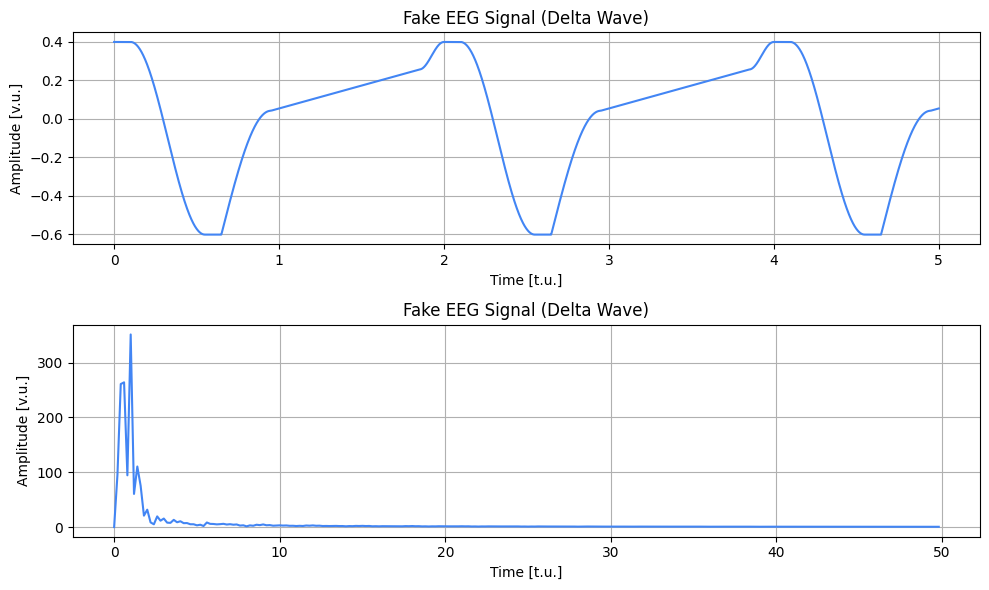

In [143]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, original, color=colors['blue'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_fft, original_fft, color=colors['blue'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Add noise

In [144]:
def add_noise_1(signal, lb_freq, ub_freq):
    np.random.seed(1742)
    noise = np.zeros_like(signal)
    for _ in range(42):
        freq = np.random.uniform(lb_freq, ub_freq)
        phase = np.random.uniform(0, 2*np.pi)
        amplitude = np.random.uniform(2/100, 5/100)
        noise += amplitude * np.sin(2 * np.pi * freq * t + phase)
    return signal + noise

noisy = add_noise_1(original, 10, 50)    
x_fft, noisy_fft = fourier_transform(noisy)

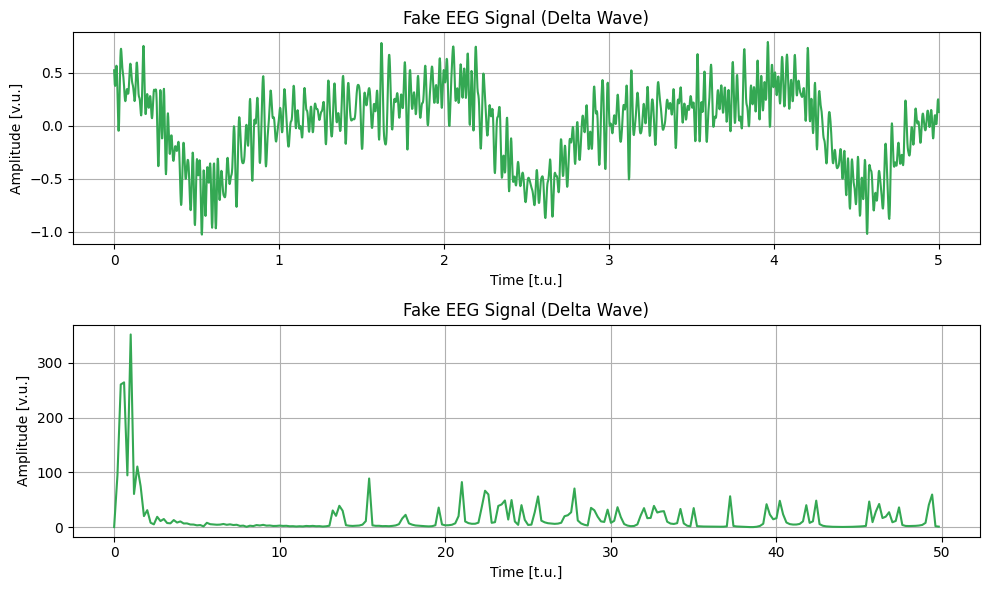

In [145]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, noisy, color=colors['green'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_fft, noisy_fft, color=colors['green'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Create filter

In [146]:
def apply_filter_1(signal, cutoff, fs):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(4, normal_cutoff, btype='low')
    return filtfilt(b, a, signal)

filtered = apply_filter_1(noisy, 10, fs)
x_fft, filtered_fft = fourier_transform(filtered)

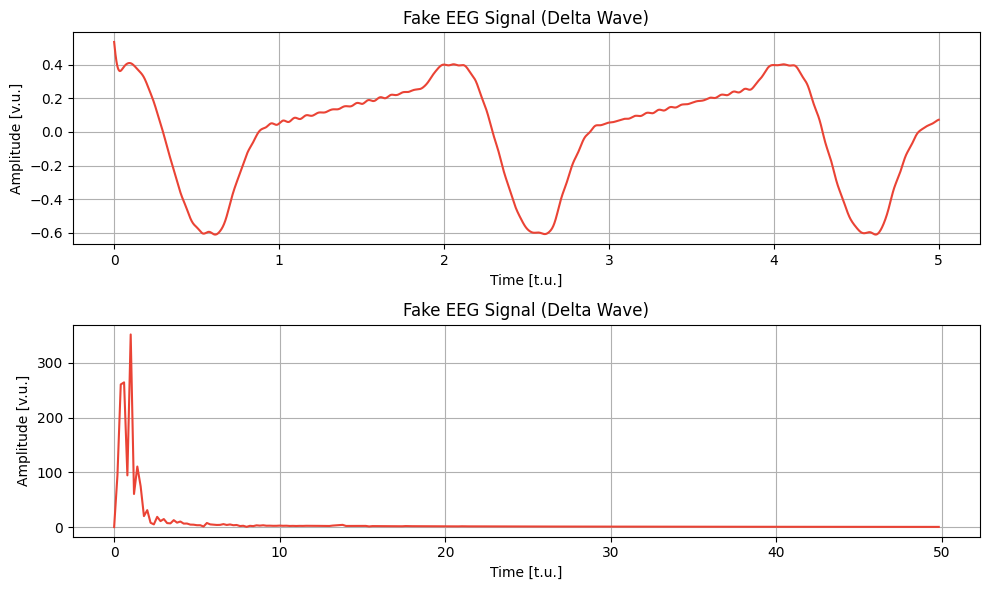

In [147]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_fft, filtered_fft, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Compare results

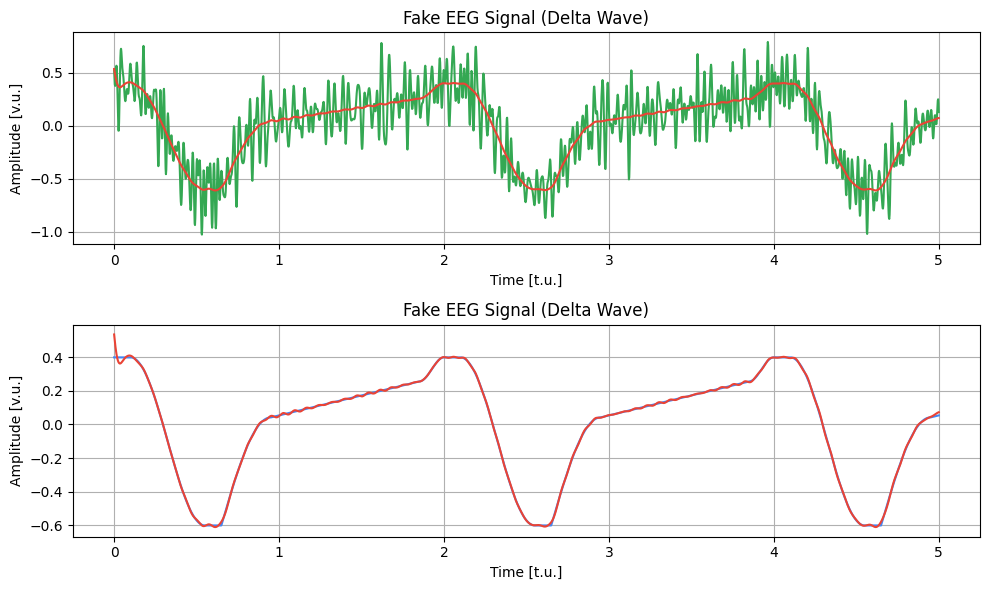

In [148]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, noisy, color=colors['green'])
plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, original, color=colors['blue'])
plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

# Signal 2

## Generate the signal

In [149]:
def generate_signal_2():
    t_mod = t % 2.0
    
    # 1. Define boolean masks for the domain segments
    c1 = (t_mod >= 0.0) & (t_mod < 0.1)   # Isovolumetric Contraction
    c2 = (t_mod >= 0.1) & (t_mod < 0.55)  # Ejection
    c3 = (t_mod >= 0.55) & (t_mod < 0.65) # Isovolumetric Relaxation
    c4 = (t_mod >= 0.65) & (t_mod < 0.95) # Rapid Filling
    c5 = (t_mod >= 0.95) & (t_mod < 1.85) # Diastasis
    c6 = (t_mod >= 1.85) & (t_mod <= 2.0) # Atrial Systole
    
    # 2. Define the corresponding mathematical mappings
    f1 = lambda x: 10.0 + 70.0 * (1.0 - np.cos(np.pi * x / 0.1)) / 2.0
    f2 = lambda x: 80.0 + 40.0 * np.sin(np.pi * (x - 0.1) / 0.45) + 10.0 * (x - 0.1) / 0.45
    f3 = lambda x: 5.0 + 85.0 * (1.0 + np.cos(np.pi * (x - 0.55) / 0.1)) / 2.0
    f4 = lambda x: 5.0 + 2.0 * np.sqrt((x - 0.65) / 0.30)
    f5 = lambda x: 7.0 + 3.0 * (x - 0.95) / 0.90
    f6 = lambda x: 10.0 + 4.0 * np.sin(np.pi * (x - 1.85) / 0.15)
    
    # 3. Assemble and return the piecewise evaluation
    sig = np.piecewise(t_mod, [c1, c2, c3, c4, c5, c6], [f1, f2, f3, f4, f5, f6])
    return (sig - sig.mean()) / (sig.max() - sig.min())

original = generate_signal_2()
x_fft, original_fft = fourier_transform(original)

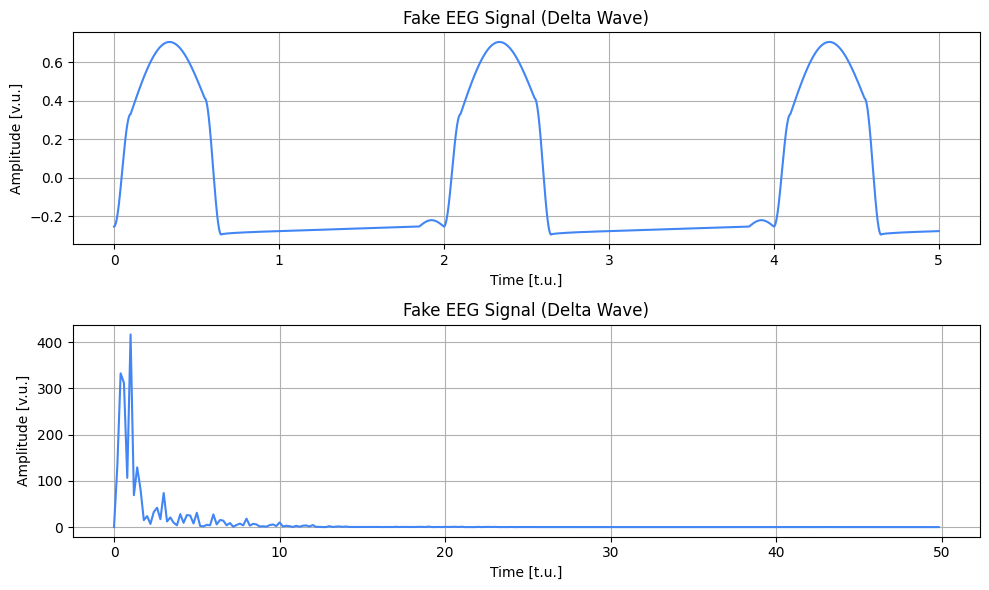

In [150]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, original, color=colors['blue'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_fft, original_fft, color=colors['blue'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Add noise

In [151]:
def add_noise_2(signal):
    np.random.seed(1742)
    noise = np.zeros_like(signal)
    jiter_no = 7
    pos = [np.random.uniform(0, duration) for _ in range(jiter_no)]
    amp = [np.random.uniform(-1, 1) for _ in range(jiter_no)]
    width = [np.random.uniform(1/1000, 1/100) for _ in range(jiter_no)]

    for i in range(int(duration)):
        for j in range(int(jiter_no)):
            peak_time = i + pos[j]
            noise += amp[j] * np.exp(-((t - peak_time)**2) / (2 * width[j]**2))
    return signal + noise

noisy = add_noise_2(original)    
x_fft, noisy_fft = fourier_transform(noisy)

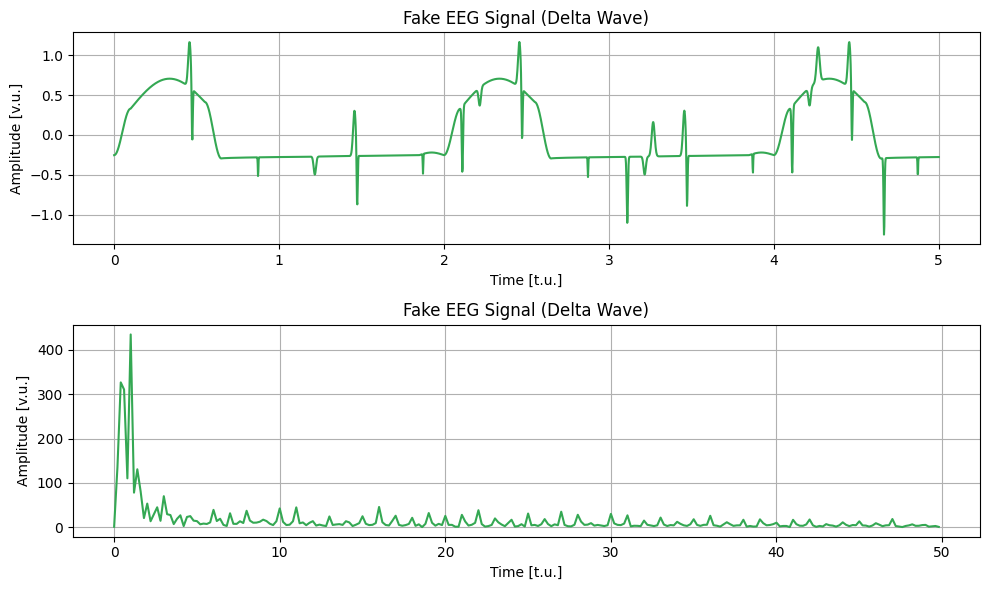

In [152]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, noisy, color=colors['green'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_fft, noisy_fft, color=colors['green'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Create filter

In [153]:
def apply_filter_2(signal, k):
    out = np.full_like(signal, np.nan, dtype=float)
    for i in range(k - 1, len(signal)):
        out[i] = np.median(signal[i - k + 1 : i + 1])
    return out

filtered = apply_filter_2(noisy, 42)
x_fft, filtered_fft = fourier_transform(filtered)

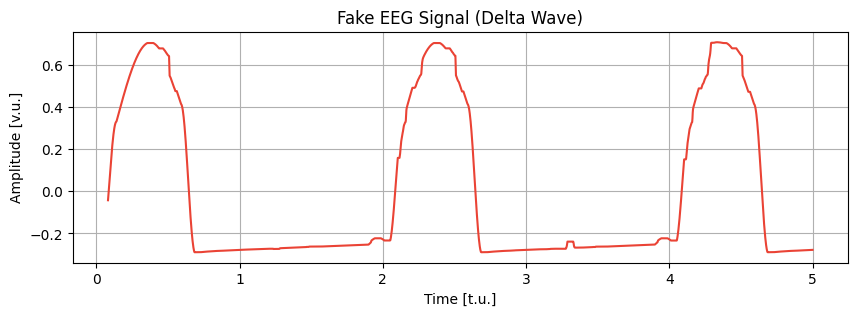

In [154]:
plt.figure(figsize=(10, 3))

plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.show()

## Compare results

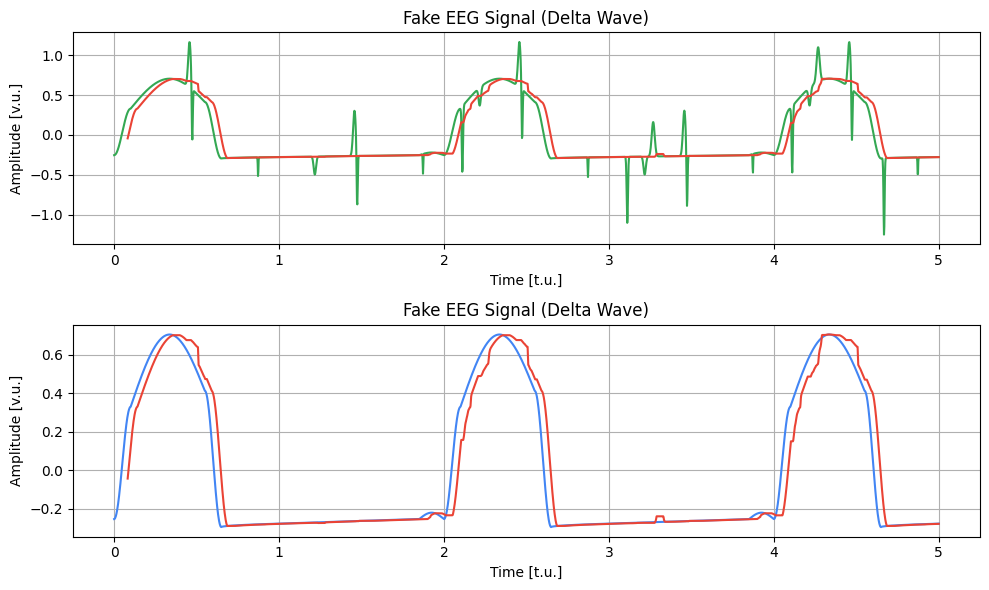

In [155]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, noisy, color=colors['green'])
plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, original, color=colors['blue'])
plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

# Signal 3

## Generate the signal

In [156]:
def generate_signal_3():
    t = np.linspace(0, duration, int(fs * duration))
    ecg = np.zeros_like(t)

    # P, Q, R, S, T peaks and widths
    peaks = {
        'P': (0.20,  0.10, 0.040), 
        'Q': (0.37, -0.10, 0.015), 
        'R': (0.40,  0.80, 0.015),
        'S': (0.43, -0.20, 0.015), 
        'T': (0.65,  0.20, 0.060)
    }

    for i in range(int(duration)):
        for _, (pos, amp, width) in peaks.items():
            peak_time = i + pos
            # add a pulse to the ecg signal
            ecg += amp * np.exp(-((t - peak_time)**2) / (2 * width**2))
    return (ecg - ecg.mean()) / (ecg.max() - ecg.min())

original = generate_signal_3()
x_fft, original_fft = fourier_transform(original)

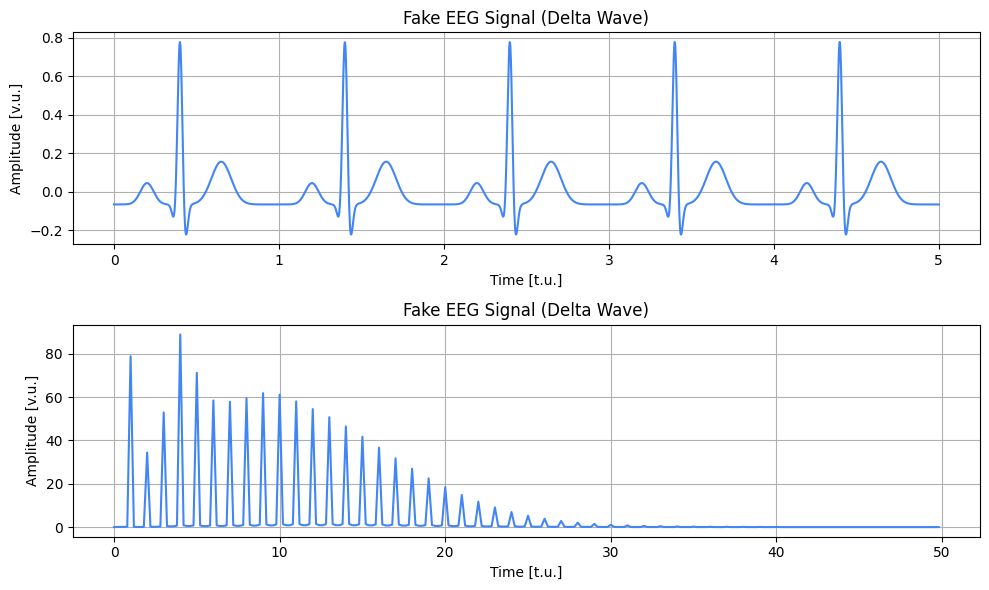

In [157]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, original, color=colors['blue'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_fft, original_fft, color=colors['blue'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Add noise

In [158]:
def add_noise_3(signal, snr_db):
    np.random.seed(1742)
    signal = np.asarray(signal, dtype=complex if np.iscomplexobj(signal) else float)
    P_s = np.mean(np.abs(signal) ** 2)
    snr_linear = 10 ** (snr_db / 10)
    P_n = P_s / snr_linear
    std = np.sqrt(P_n / 2) if np.iscomplexobj(signal) else np.sqrt(P_n)
    noise = (std * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
             if np.iscomplexobj(signal) else std * np.random.randn(*signal.shape))
    return signal + noise

noisy = add_noise_3(original, 17)    
x_fft, noisy_fft = fourier_transform(noisy)

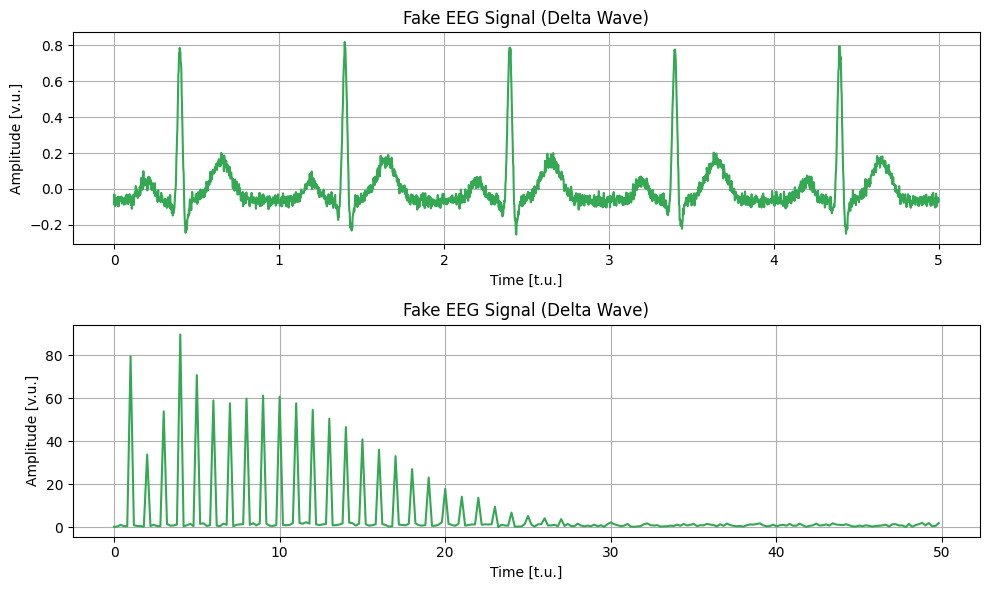

In [159]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, noisy, color=colors['green'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_fft, noisy_fft, color=colors['green'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Create filter

In [160]:
def apply_filter_3(signal):
    # ── Wavelet decomposition ─────────────────────────────────────────────────────
    wavelet = 'db4'
    # wavedec returns [cA_n, cD_n, cD_{n-1}, ..., cD_1]
    # i.e. coeffs[0]  = coarse approximation (lowest freq)
    #      coeffs[-1] = finest detail (highest freq, most noise)
    coeffs = pywt.wavedec(signal, wavelet)

    # ── Step 1: noise variance estimate via MAD on finest detail band ─────────────
    # cD1 (coeffs[-1]) is the highest-frequency subband — dominated by noise.
    # MAD estimator: σ̂ = MAD / 0.6745
    # The 0.6745 constant = Φ⁻¹(0.75) — it converts MAD to a consistent
    # estimator of σ for a Gaussian distribution.
    cD1  = coeffs[-1]
    mad  = np.median(np.abs(cD1 - np.median(cD1)))
    sigma = mad / 0.6745

    # ── Step 2: universal (Donoho-Johnstone) threshold ───────────────────────────
    # λ = σ√(2 ln N)  — asymptotically optimal for removing Gaussian noise
    # while preserving signal features. Derived from the expected maximum
    # of N i.i.d. N(0,1) variables.
    N = len(signal)
    lambda_thr = sigma * np.sqrt(2 * np.log(N))

    # ── Step 3: soft thresholding on detail coefficients only ────────────────────
    # Soft threshold: sign(x) * max(|x| - λ, 0)
    # Shrinks all coefficients toward zero — avoids hard-threshold's
    # discontinuity (Gibbs-like artefacts) at the cost of slight bias.
    # cA (coeffs[0]) is NOT thresholded — it encodes the signal's DC/low-freq
    # structure and thresholding it would distort the baseline.
    denoised_coeffs = [coeffs[0]] + [
        pywt.threshold(c, value=lambda_thr, mode='soft')
        for c in coeffs[1:]
    ]

    # ── Step 4: inverse DWT ───────────────────────────────────────────────────────
    reconstructed = pywt.waverec(denoised_coeffs, wavelet)
    # waverec can return length 1025 due to odd-length padding — trim to match t
    reconstructed = reconstructed[:len(t)]
    return reconstructed

filtered = apply_filter_3(noisy)
x_fft, filtered_fft = fourier_transform(filtered)

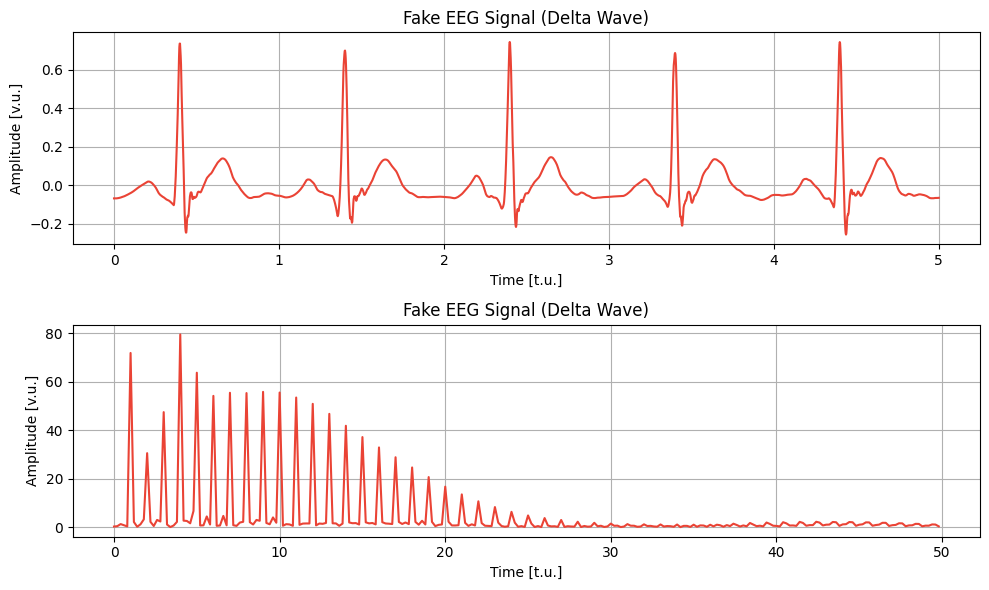

In [161]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_fft, filtered_fft, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Compare results

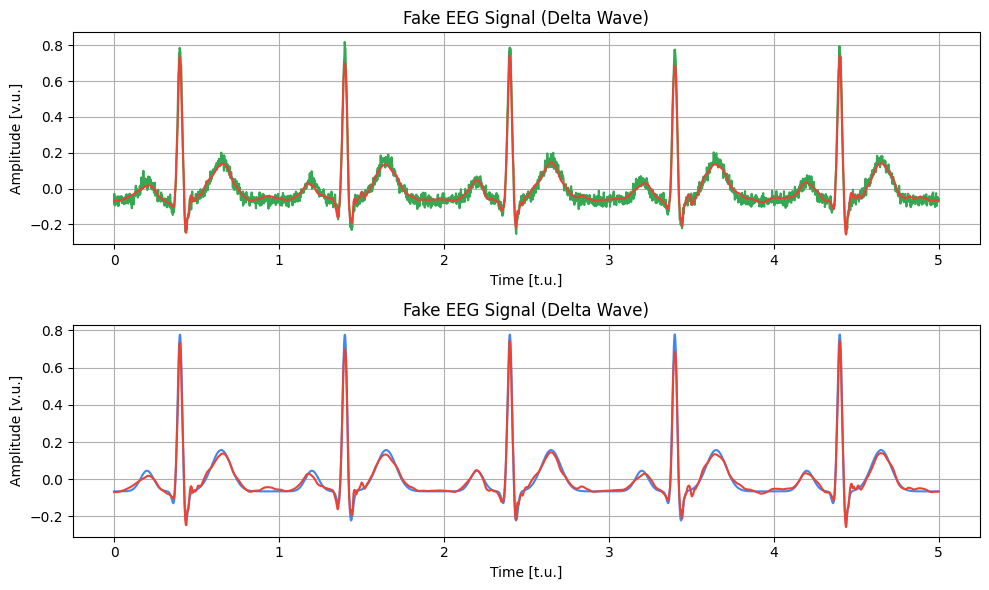

In [162]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, noisy, color=colors['green'])
plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, original, color=colors['blue'])
plt.plot(t, filtered, color=colors['red'])
plt.title('Fake EEG Signal (Delta Wave)')
plt.xlabel('Time [t.u.]')
plt.ylabel('Amplitude [v.u.]')
plt.grid(True)

plt.tight_layout()
plt.show()